[*********************100%***********************]  10 of 10 completed


Ejecutando AG Multiobjetivo (Max Retorno, Min CVaR, Min Volatilidad)...
n_gen |  n_eval |  n_nds  |     eps      |  indicator  
    1 |     100 |      11 |            - |            -
    2 |     200 |      11 |  0.282531624 |        ideal
    3 |     300 |      18 |  0.187971435 |        ideal
    4 |     400 |      27 |  0.064097010 |        ideal
    5 |     500 |      42 |  0.087344022 |        ideal
    6 |     600 |      66 |  0.010566391 |        ideal
    7 |     700 |      85 |  0.116345623 |        ideal
    8 |     800 |     100 |  0.073154828 |        ideal
    9 |     900 |     100 |  0.038570331 |        ideal
   10 |    1000 |     100 |  0.041405796 |        ideal
   11 |    1100 |     100 |  0.094763045 |        nadir
   12 |    1200 |     100 |  0.040336415 |        ideal
   13 |    1300 |     100 |  0.032796077 |        ideal
   14 |    1400 |     100 |  0.040946753 |        ideal
   15 |    1500 |     100 |  0.037771097 |        ideal
   16 |    1600 |     100 |  0.0

[*********************100%***********************]  1 of 1 completed


            Modelo Retorno 2015 Volatilidad 2015 Sharpe Ratio CVaR 95% Herfindahl Kurtosis
         Markowitz      -0.4901           0.7446      -0.6985   0.1180     1.0000   0.2293
AG (Multiobjetivo)       0.0985           0.5264       0.1301   0.0878     0.4884   1.5216
           IBEX 35      -1.1491           0.6251      -1.8462                             


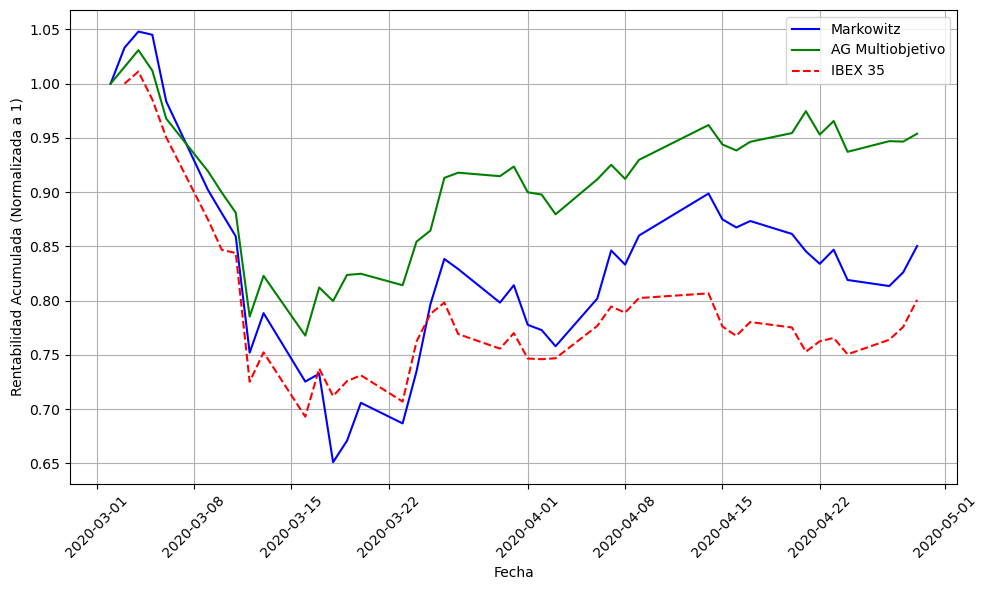

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import cvxpy as cp
import math
import random
from collections import defaultdict
from scipy.stats import kurtosis
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

# === 1. Tickers y sectores de 10 empresas del IBEX 35 seleccionadas (2015)
TICKERS = {
    "SAN.MC": "Financiero", "BBVA.MC": "Financiero", "ITX.MC": "Consumo Discrecional",
    "IBE.MC": "Energía Eléctrica", "REP.MC": "Energía (Petróleo y Gas)",
    "TEF.MC": "Telecomunicaciones", "ACS.MC": "Construcción",
    "FER.MC": "Construcción", "GRF.MC": "Salud", "AMS.MC": "Tecnología"
}
tickers = list(TICKERS.keys())

# === 2. Descargar precios: sept 2019 – abril 2020
data = yf.download(tickers, start="2019-01-01", end="2020-04-30", auto_adjust=True)["Close"]
returns = data.pct_change().dropna()

# === 3. Dividir en entrenamiento (sept 2019 – feb 2020) y test (marzo–abril 2020)
train_returns = returns.loc["2019-01-01":"2019-12-31"]
test_returns  = returns.loc["2020-03-01":"2020-04-30"]

# === 5. Media y covarianza anualizadas del entrenamiento (para Markowitz)
mean_mk = train_returns.mean() * 252
cov_mk = train_returns.cov() * 252
mu_mk = mean_mk.values
Sigma_mk = cov_mk.values
n = len(mu_mk)

# === 6. Optimización de cartera (Markowitz)
sigma_max = 0.20  # límite de volatilidad

w_mk_opt = cp.Variable(n)
objective_mk = cp.Maximize(mu_mk @ w_mk_opt)
constraints_mk = [
    cp.quad_form(w_mk_opt, Sigma_mk) <= sigma_max**2,
    cp.sum(w_mk_opt) == 1,
    w_mk_opt >= 0
]
prob_mk = cp.Problem(objective_mk, constraints_mk)
prob_mk.solve()

# === 7. Evaluación en el año no visto (2015) - Markowitz
w_opt_mk_values = w_mk_opt.value
ret_mk_2015 = (test_returns.mean() * 252) @ w_opt_mk_values
vol_mk_2015 = np.sqrt(w_opt_mk_values @ (test_returns.cov() * 252).values @ w_opt_mk_values)
sharpe_mk_2015 = (ret_mk_2015 - 0.03) / vol_mk_2015

# === 8. Cálculo de CVaR, Herfindahl y Kurtosis en 2015 - Markowitz
port_daily_returns_mk = test_returns @ w_opt_mk_values
sorted_returns_mk = np.sort(port_daily_returns_mk)
cvar_mk_2015 = -sorted_returns_mk[:int(0.05 * len(sorted_returns_mk))].mean()
herf_mk_2015 = np.sum(w_opt_mk_values**2)
kurt_mk_2015 = kurtosis(port_daily_returns_mk)

# === 9. Algoritmo Genético - Definición de variables y funciones
mean_ag_train = train_returns.mean() * 252
cov_ag_train = train_returns.cov() * 252

MAX_VOL = 0.20
RISK_FREE_RATE = 0.03
POP, GEN, MUT_RATE = 100, 200, 0.10

def base_penalty(w):
    pen = abs(w.sum() - 1) * 1e3
    vol = math.sqrt(w @ cov_ag_train.values @ w)
    if vol > MAX_VOL:
        pen += (vol - MAX_VOL) * 100
    return pen

def generate_individual():
    n_tickers = len(tickers)
    for _ in range(1000):
        k = np.random.randint(1, n_tickers + 1)
        idx = np.random.choice(n_tickers, k, replace=False)
        w = np.zeros(n_tickers)
        w_sub = np.random.dirichlet(np.ones(k))
        w[idx] = w_sub
        if math.sqrt(w @ cov_ag_train.values @ w) > MAX_VOL: continue
        return w
    raise ValueError("No se pudo generar individuo válido")

def init_pop():
    return np.array([generate_individual() for _ in range(POP)])

def tournament_selection(pop, fits, k=3):
    idx = np.random.choice(len(pop), k, replace=False)
    return pop[idx[np.argmax(fits[idx])]]

def crossover(p1, p2):
    alpha = np.random.rand()
    child = alpha * p1 + (1 - alpha) * p2
    if child.sum() == 0:
        return np.ones(len(child)) / len(child)
    return child / child.sum()

def mutate(w):
    if np.random.rand() < MUT_RATE:
        i = np.random.randint(len(w))
        delta = np.random.normal(scale=0.02)
        w[i] = w[i] + delta
        if w.sum() == 0:
            return np.ones(len(w)) / len(w)
        w /= w.sum()
    return w

def metr_ga(w):
    r = (test_returns.mean() * 252) @ w
    v = math.sqrt(w @ (test_returns.cov()*252).values @ w)
    s = (r - RISK_FREE_RATE) / v
    c = -np.sort(test_returns @ w)[:int(0.05*len(test_returns))].mean()
    h = (w**2).sum()
    k = kurtosis(test_returns @ w)
    return r, v, s, c, h, k

# === 10. AG Multiobjetivo (Maximizar Retorno, Minimizar CVaR, Minimizar Volatilidad) ===
class PortfolioProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=len(tickers),
            n_obj=4,  # Añadimos kurtosis como cuarto objetivo
            n_constr=0,
            xl=np.zeros(len(tickers)),
            xu=np.ones(len(tickers))
        )

    def _evaluate(self, w, out, *args, **kwargs):
        if w.sum() == 0:
            w = np.ones(len(w)) / len(w)
        else:
            w = w / w.sum()

        mu_w = w @ mean_ag_train.values
        cvar_w = -np.sort(train_returns @ w)[:int(0.05 * len(train_returns))].mean()
        sig_w = math.sqrt(w @ cov_ag_train.values @ w)
        kurt_w = kurtosis(train_returns @ w)

        penalty = base_penalty(w)

        out["F"] = [
            -mu_w + penalty,   # Maximizar retorno
            cvar_w + penalty,  # Minimizar CVaR
            sig_w + penalty,   # Minimizar volatilidad
            kurt_w + penalty   # Minimizar kurtosis
        ]


# Ejecutar AG multiobjetivo con NSGA-II
print("Ejecutando AG Multiobjetivo (Max Retorno, Min CVaR, Min Volatilidad)...")
problem = PortfolioProblem()
algorithm = NSGA2(pop_size=100)
res = minimize(
    problem,
    algorithm,
    ('n_gen', 200),
    seed=42,
    verbose=True
)

# Seleccionar una solución del frente de Pareto (la de mejor Sharpe)
pareto_weights = res.X
pareto_objectives = res.F

# Calcular el Sharpe Ratio para cada solución en el frente de Pareto (usando datos de prueba)
sharpe_ratios = []
for w in pareto_weights:
    if w.sum() == 0:
        w = np.ones(len(w)) / len(w)
    else:
        w = w / w.sum()
    r = (test_returns.mean() * 252) @ w
    v = math.sqrt(w @ (test_returns.cov()*252).values @ w)
    s = (r - RISK_FREE_RATE) / v if v > 0 else 0
    sharpe_ratios.append(s)

# Seleccionar la solución con el mejor Sharpe Ratio
best_idx = np.argmax(sharpe_ratios)
best_multi_weights = pareto_weights[best_idx]
if best_multi_weights.sum() == 0:
    best_multi_weights = np.ones(len(best_multi_weights)) / len(best_multi_weights)
else:
    best_multi_weights = best_multi_weights / best_multi_weights.sum()

# Calcular métricas para la solución seleccionada
ret_multi, vol_multi, sharpe_multi, cvar_multi, herf_multi, kurt_multi = metr_ga(best_multi_weights)

# === 11. Cargar datos del IBEX 35 para 2015 y calcular métricas
ibex_data = yf.download("^IBEX", start="2020-03-01", end="2020-04-30", auto_adjust=True)["Close"]
ibex_returns = ibex_data.pct_change().dropna()

ret_ibex_2015 = ibex_returns.mean() * 252
vol_ibex_2015 = ibex_returns.std() * np.sqrt(252)
risk_free_rate_ibex = 0.005
sharpe_ibex_2015 = (ret_ibex_2015 - risk_free_rate_ibex) / vol_ibex_2015
cvar_ibex_2015 = np.nan
herfindahl_ibex_2015 = np.nan
kurt_ibex_2015 = np.nan

# === 12. Crear tabla comparativa
data_comp = {
    "Modelo": ["Markowitz", "AG (Multiobjetivo)", "IBEX 35"],
    "Retorno 2015": [ret_mk_2015, ret_multi, ret_ibex_2015],
    "Volatilidad 2015": [vol_mk_2015, vol_multi, vol_ibex_2015],
    "Sharpe Ratio": [sharpe_mk_2015, sharpe_multi, sharpe_ibex_2015],
    "CVaR 95%": [cvar_mk_2015, cvar_multi, cvar_ibex_2015],
    "Herfindahl": [herf_mk_2015, herf_multi, herfindahl_ibex_2015],
    "Kurtosis": [kurt_mk_2015, kurt_multi, kurt_ibex_2015]
}

df_comparison = pd.DataFrame(data_comp)

# Reemplazar NaN por cadenas vacías
df_comparison = df_comparison.fillna("")

# Formatear e imprimir la tabla
def format_float(x):
    try:
        return f'{float(x):.4f}'
    except ValueError:
        return x

formatted_df = df_comparison.copy()
for col in ["Retorno 2015", "Volatilidad 2015", "Sharpe Ratio", "CVaR 95%", "Herfindahl", "Kurtosis"]:
    formatted_df[col] = formatted_df[col].apply(format_float)

print(formatted_df.to_string(index=False))

# === 13. Gráfico de rendimiento acumulado ===
# Calcular los retornos diarios acumulados para marzo-abril 2020
port_returns_mk = test_returns @ w_opt_mk_values
port_returns_multi = test_returns @ best_multi_weights
cum_returns_mk = (1 + port_returns_mk).cumprod()
cum_returns_multi = (1 + port_returns_multi).cumprod()
cum_returns_ibex = (1 + ibex_returns).cumprod()

# Normalizar al valor inicial (1 al inicio de marzo 2020)
cum_returns_mk = cum_returns_mk / cum_returns_mk.iloc[0]
cum_returns_multi = cum_returns_multi / cum_returns_multi.iloc[0]
cum_returns_ibex = cum_returns_ibex / cum_returns_ibex.iloc[0]

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(cum_returns_mk.index, cum_returns_mk, label='Markowitz', color='blue')
plt.plot(cum_returns_multi.index, cum_returns_multi, label='AG Multiobjetivo', color='green')
plt.plot(cum_returns_ibex.index, cum_returns_ibex, label='IBEX 35', color='red', linestyle='--')
plt.title('')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad Acumulada (Normalizada a 1)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cumulative_returns.png')

In [2]:
# Comparativa de pesos entre Markowitz y GA
pesos_comparados = pd.DataFrame({
    'Ticker': tickers,
    'Peso Markowitz': w_opt_mk_values,
    'Peso GA': best_multi_weights
})
print(pesos_comparados)

    Ticker  Peso Markowitz   Peso GA
0   SAN.MC    1.111842e-10  0.000004
1  BBVA.MC    8.151005e-11  0.000224
2   ITX.MC    5.391154e-11  0.000137
3   IBE.MC    1.000000e+00  0.484538
4   REP.MC    9.823405e-11  0.503531
5   TEF.MC   -2.540366e-10  0.000059
6   ACS.MC   -1.134317e-10  0.011207
7   FER.MC    2.703072e-11  0.000120
8   GRF.MC    8.579517e-12  0.000165
9   AMS.MC   -1.610831e-11  0.000014
